# Current results: batched `_get_x_best`

This notebook analyzes the results currently available in `04_compare_fix`. It is deliberately safe to rerun while the original jobs are still running: completed fixed runs use their final summaries, while paired runtime comparisons use only the exact run-history prefix available in **both** modes.

The comparison is:

- ACLib `cplex_regions200` surrogate benchmark;
- 150 instances with 148 instance features;
- SMAC random forest with 10 trees, maximum depth 20, and PCA disabled;
- `retrain_after=8`, 3,000 trials, seeds 0 and 1, one requested CPU;
- `original_singleton`: one high-level `predict_marginalized()` invocation per accumulated configuration inside each `_get_x_best` execution;
- `fixed_batched`: one high-level `predict_marginalized(X)` invocation per `_get_x_best` execution, with all accumulated configurations in `X`.

The batching changes invocation/dispatch overhead. It does **not** remove the underlying configuration × instance × tree prediction work.

In [1]:
from datetime import datetime
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

relative = Path("experiments/aclib/cplex_regions200_surrogate/04_compare_fix")
candidates = [Path.cwd(), Path.cwd() / relative]
HERE = next(path.resolve() for path in candidates if (path / "run_compare.py").is_file())
RESULTS = HERE / "results"
MODES = ("original_singleton", "fixed_batched")
SEEDS = (0, 1)
COLORS = {"original_singleton": "#d95f02", "fixed_batched": "#1b9e77"}
LABELS = {"original_singleton": "Original singleton", "fixed_batched": "Fixed batched"}

def read_json(path, required=True):
    if not path.is_file():
        if required:
            raise FileNotFoundError(path)
        return None
    return json.loads(path.read_text())

def load_run(mode, seed):
    directory = RESULTS / mode / str(seed)
    history = read_json(directory / "runhistory.json")
    trials = pd.DataFrame(history["data"]).sort_values(["starttime", "endtime"]).reset_index(drop=True)
    return {
        "mode": mode,
        "seed": seed,
        "directory": directory,
        "history": history,
        "trials": trials,
        "metadata": read_json(directory / "comparison_metadata.json"),
        "optimization": read_json(directory / "optimization.json"),
        "summary": read_json(directory / "runtime_summary.json", required=False),
        "events": read_json(directory / "runtime_events.json", required=False),
    }

# One in-memory snapshot keeps every table internally consistent even if a job saves again.
snapshot_at = datetime.now().astimezone()
runs = {(mode, seed): load_run(mode, seed) for mode in MODES for seed in SEEDS}
display(Markdown(f"**Snapshot loaded:** {snapshot_at:%Y-%m-%d %H:%M:%S %Z}"))

**Snapshot loaded:** 2026-07-27 20:10:44 CEST

## 1. Run status and experimental controls

`history_hours` ends at the last completed target evaluation and is the quantity used for equal-trial comparisons. `reported_wall_hours` uses the final runtime summary when available, otherwise SMAC's current `used_walltime`.

In [2]:
def history_elapsed_seconds(run, n=None):
    trials = run["trials"]
    if n is None:
        n = len(trials)
    if n == 0:
        return np.nan
    return float(trials.iloc[n - 1]["endtime"] - trials.iloc[0]["starttime"])

status_rows = []
for (mode, seed), run in runs.items():
    summary = run["summary"]
    optimization = run["optimization"]
    complete = bool(summary and summary.get("finished_trials") == summary.get("n_trials") and not summary.get("error"))
    reported_wall = summary["walltime_seconds"] if complete else optimization["used_walltime"]
    target_seconds = summary["target_function_walltime_seconds"] if complete else optimization["used_target_function_walltime"]
    status_rows.append({
        "mode": LABELS[mode],
        "seed": seed,
        "host": run["metadata"]["hostname"].split(".")[0],
        "status": "complete" if complete else "partial / running",
        "finished_trials": len(run["trials"]),
        "configurations": len(run["history"]["configs"]),
        "history_hours": history_elapsed_seconds(run) / 3600,
        "reported_wall_hours": reported_wall / 3600,
        "target_seconds": target_seconds,
    })

status_df = pd.DataFrame(status_rows).sort_values(["mode", "seed"]).reset_index(drop=True)
display(status_df.round({"history_hours": 3, "reported_wall_hours": 3, "target_seconds": 2}))

settings = runs[("fixed_batched", 0)]["metadata"]
display(pd.DataFrame({
    "setting": ["benchmark", "instances", "instance features", "RF trees", "RF max depth", "PCA", "retrain_after", "trial budget", "seeds", "workers"],
    "value": ["cplex_regions200 surrogate", settings["n_instances"], 148, 10, settings["depth"], "disabled", settings["retrain_after"], settings["n_trials"], "0, 1", 1],
}))

,mode,seed,host,status,finished_trials,configurations,history_hours,reported_wall_hours,target_seconds
0,Fixed batched,0,r23m0144,complete,3000,2026,3.701,3.702,19.36
1,Fixed batched,1,r23m0087,complete,3000,2035,2.799,2.799,15.21
2,Original singleton,0,r23m0154,complete,3000,2026,7.633,7.633,16.92
3,Original singleton,1,r23m0144,complete,3000,2035,9.640,9.641,15.84


,setting,value
0,benchmark,cplex_regions200 surrogate
1,instances,150
2,instance features,148
3,RF trees,10
4,RF max depth,20
5,PCA,disabled
6,retrain_after,8
7,trial budget,3000
8,seeds,"0, 1"
9,workers,1


## 2. Did the fix change SMAC's decisions?

For each seed, compare every currently shared trial. Timing fields are intentionally excluded. The check includes the selected configuration ID and value, instance, target seed, budget, cost, and status.

In [3]:
TRIAL_FIELDS = ("config_id", "instance", "seed", "budget", "cost", "status")

def trial_signature(entry):
    return tuple(entry[field] for field in TRIAL_FIELDS)

def compare_prefix(seed):
    original = runs[("original_singleton", seed)]
    fixed = runs[("fixed_batched", seed)]
    n = min(len(original["trials"]), len(fixed["trials"]))
    original_data = original["history"]["data"][:n]
    fixed_data = fixed["history"]["data"][:n]
    mismatches = [i for i, (a, b) in enumerate(zip(original_data, fixed_data)) if trial_signature(a) != trial_signature(b)]
    ids = {str(entry["config_id"]) for entry in original_data} | {str(entry["config_id"]) for entry in fixed_data}
    config_mismatches = [config_id for config_id in ids if original["history"]["configs"].get(config_id) != fixed["history"]["configs"].get(config_id)]
    return {
        "seed": seed,
        "comparable_trials": n,
        "referenced_configurations": len(ids),
        "configuration_value_mismatches": len(config_mismatches),
        "trial_mismatches": len(mismatches),
        "first_trial_mismatch": mismatches[0] + 1 if mismatches else None,
        "exact_prefix_match": not mismatches and not config_mismatches,
    }

correctness_df = pd.DataFrame(compare_prefix(seed) for seed in SEEDS)
display(correctness_df)
assert correctness_df["exact_prefix_match"].all(), "The paired trajectories diverged; inspect before using timing comparisons."

,seed,comparable_trials,referenced_configurations,configuration_value_mismatches,trial_mismatches,first_trial_mismatch,exact_prefix_match
0,0,3000,2026,0,0,None,True
1,1,3000,2035,0,0,None,True


## 3. End-to-end runtime at equal trial counts

These are paired comparisons at identical completed-trial checkpoints. They include the full optimization loop between the first target evaluation and the checkpoint, not just `_get_x_best`.

,seed,trials,configurations,original_minutes,fixed_minutes,speedup,time_reduction_pct
0,0,500,121,6.332,6.705,0.944,-5.897
1,0,1000,330,28.479,25.439,1.119,10.674
2,0,1500,814,101.636,71.902,1.414,29.256
3,0,2000,1310,218.133,128.458,1.698,41.110
4,0,2500,1742,350.501,182.780,1.918,47.852
5,0,3000,2026,457.983,222.086,2.062,51.508
6,1,500,132,6.029,4.554,1.324,24.461
7,1,1000,263,20.821,13.266,1.570,36.286
8,1,1500,747,120.266,49.339,2.438,58.975
9,1,2000,1247,270.700,89.861,3.012,66.804


**Pooled across seeds (ratio of summed times, not mean of ratios):**

,trials,seeds,original_minutes,fixed_minutes,speedup,time_reduction_pct
0,500,2,12.361,11.259,1.098,8.910
1,1000,2,49.299,38.704,1.274,21.491
2,1500,2,221.902,121.241,1.830,45.363
3,2000,2,488.832,218.319,2.239,55.339
4,2500,2,736.114,303.650,2.424,58.750
5,3000,2,1036.399,390.017,2.657,62.368


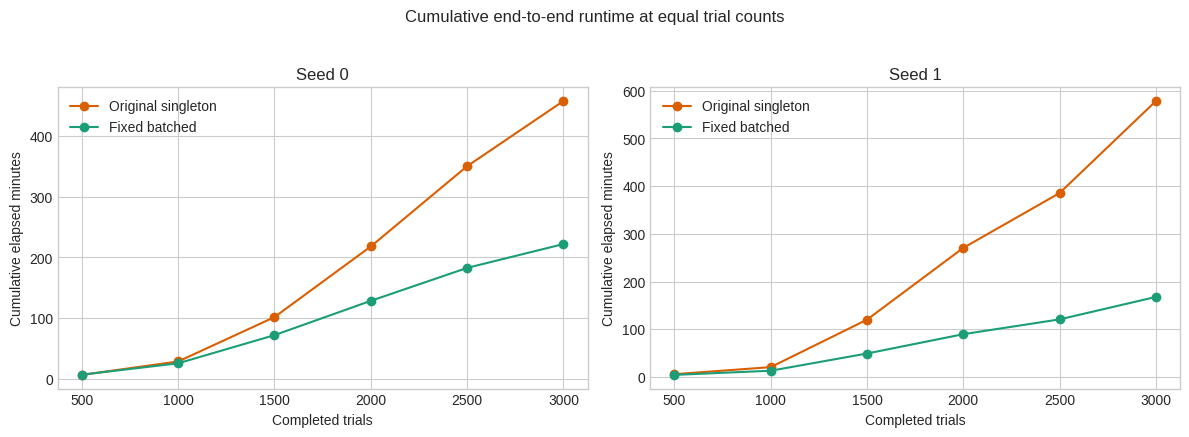

In [4]:
checkpoint_rows = []
for seed in SEEDS:
    limit = min(len(runs[(mode, seed)]["trials"]) for mode in MODES)
    for n in range(500, limit + 1, 500):
        original_seconds = history_elapsed_seconds(runs[("original_singleton", seed)], n)
        fixed_seconds = history_elapsed_seconds(runs[("fixed_batched", seed)], n)
        config_count = int(runs[("fixed_batched", seed)]["trials"].iloc[:n]["config_id"].nunique())
        checkpoint_rows.append({
            "seed": seed,
            "trials": n,
            "configurations": config_count,
            "original_minutes": original_seconds / 60,
            "fixed_minutes": fixed_seconds / 60,
            "speedup": original_seconds / fixed_seconds,
            "time_reduction_pct": 100 * (1 - fixed_seconds / original_seconds),
        })

checkpoint_df = pd.DataFrame(checkpoint_rows)
pooled_checkpoint_df = checkpoint_df.groupby("trials", as_index=False).agg(
    seeds=("seed", "nunique"),
    original_minutes=("original_minutes", "sum"),
    fixed_minutes=("fixed_minutes", "sum"),
)
pooled_checkpoint_df["speedup"] = pooled_checkpoint_df["original_minutes"] / pooled_checkpoint_df["fixed_minutes"]
pooled_checkpoint_df["time_reduction_pct"] = 100 * (1 - pooled_checkpoint_df["fixed_minutes"] / pooled_checkpoint_df["original_minutes"])

display(checkpoint_df.round(3))
display(Markdown("**Pooled across seeds (ratio of summed times, not mean of ratios):**"))
display(pooled_checkpoint_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
for seed, ax in zip(SEEDS, axes):
    part = checkpoint_df[checkpoint_df.seed == seed]
    ax.plot(part.trials, part.original_minutes, marker="o", color=COLORS["original_singleton"], label=LABELS["original_singleton"])
    ax.plot(part.trials, part.fixed_minutes, marker="o", color=COLORS["fixed_batched"], label=LABELS["fixed_batched"])
    ax.set(title=f"Seed {seed}", xlabel="Completed trials", ylabel="Cumulative elapsed minutes")
    ax.legend()
fig.suptitle("Cumulative end-to-end runtime at equal trial counts", y=1.03)
fig.tight_layout()
plt.show()

### Runtime within each 500-trial block

The interval view is more diagnostic than one headline number: if batching addresses a history-size-dependent problem, the speedup should grow as more configurations accumulate.

**Per seed:**

,seed,interval,original_minutes,fixed_minutes,speedup,time_reduction_pct
0,0,0–500,6.332,6.705,0.944,-5.897
1,0,"500–1,000",22.147,18.734,1.182,15.412
2,0,"1,000–1,500",73.158,46.463,1.575,36.489
3,0,"1,500–2,000",116.496,56.556,2.060,51.453
4,0,"2,000–2,500",132.368,54.322,2.437,58.961
5,0,"2,500–3,000",107.483,39.306,2.735,63.430
6,1,0–500,6.029,4.554,1.324,24.461
7,1,"500–1,000",14.792,8.712,1.698,41.106
8,1,"1,000–1,500",99.445,36.073,2.757,63.725
9,1,"1,500–2,000",150.434,40.522,3.712,73.063


**Pooled mean time and pooled speedup:**

,interval,original_minutes,fixed_minutes,speedup,time_reduction_pct
0,0–500,6.180,5.630,1.098,8.910
1,"500–1,000",18.469,13.723,1.346,25.701
2,"1,000–1,500",86.302,41.268,2.091,52.181
3,"1,500–2,000",133.465,48.539,2.750,63.632
4,"2,000–2,500",123.641,42.665,2.898,65.492
5,"2,500–3,000",150.143,43.183,3.477,71.238


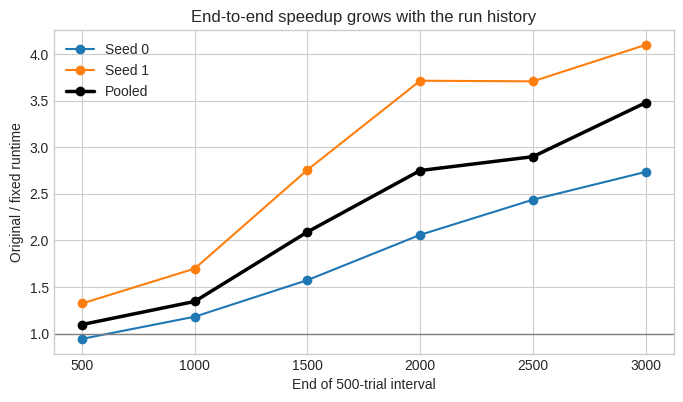

In [5]:
interval_rows = []
for seed in SEEDS:
    part = checkpoint_df[checkpoint_df.seed == seed].sort_values("trials").copy()
    previous_original = previous_fixed = 0.0
    previous_trial = 0
    for row in part.itertuples():
        original = row.original_minutes - previous_original
        fixed = row.fixed_minutes - previous_fixed
        interval_rows.append({
            "seed": seed,
            "interval": f"{previous_trial:,}–{row.trials:,}",
            "interval_end": row.trials,
            "original_minutes": original,
            "fixed_minutes": fixed,
            "speedup": original / fixed,
            "time_reduction_pct": 100 * (1 - fixed / original),
        })
        previous_original, previous_fixed, previous_trial = row.original_minutes, row.fixed_minutes, row.trials

interval_df = pd.DataFrame(interval_rows)
pooled_interval_df = interval_df.groupby(["interval", "interval_end"], as_index=False, sort=False).agg(
    seeds=("seed", "nunique"),
    original_minutes=("original_minutes", "sum"),
    fixed_minutes=("fixed_minutes", "sum"),
)
pooled_interval_df[["original_minutes", "fixed_minutes"]] /= pooled_interval_df["seeds"].to_numpy()[:, None]
pooled_interval_df["speedup"] = pooled_interval_df["original_minutes"] / pooled_interval_df["fixed_minutes"]
pooled_interval_df["time_reduction_pct"] = 100 * (1 - pooled_interval_df["fixed_minutes"] / pooled_interval_df["original_minutes"])

display(Markdown("**Per seed:**"))
display(interval_df.drop(columns="interval_end").round(3))
display(Markdown("**Pooled mean time and pooled speedup:**"))
display(pooled_interval_df.drop(columns=["interval_end", "seeds"]).round(3))

fig, ax = plt.subplots(figsize=(8, 4.2))
for seed in SEEDS:
    part = interval_df[interval_df.seed == seed]
    ax.plot(part.interval_end, part.speedup, marker="o", linewidth=1.5, label=f"Seed {seed}")
ax.plot(pooled_interval_df.interval_end, pooled_interval_df.speedup, marker="o", color="black", linewidth=2.5, label="Pooled")
ax.axhline(1, color="gray", linewidth=1)
ax.set(xlabel="End of 500-trial interval", ylabel="Original / fixed runtime", title="End-to-end speedup grows with the run history")
ax.legend()
plt.show()

### Latest exact common prefix

This table uses all currently comparable trials, even when the latest count is not a multiple of 500. For an unfinished original run, `lower_bound_final_speedup` is only a mathematical lower bound: the original has already spent that much time, while the fixed 3,000-trial runtime is final.

In [6]:
latest_rows = []
for seed in SEEDS:
    original = runs[("original_singleton", seed)]
    fixed = runs[("fixed_batched", seed)]
    n = min(len(original["trials"]), len(fixed["trials"]))
    original_seconds = history_elapsed_seconds(original, n)
    fixed_seconds = history_elapsed_seconds(fixed, n)
    fixed_final_seconds = fixed["summary"]["walltime_seconds"]
    latest_rows.append({
        "seed": seed,
        "common_trials": n,
        "configurations": int(fixed["trials"].iloc[:n]["config_id"].nunique()),
        "original_hours_at_prefix": original_seconds / 3600,
        "fixed_hours_at_prefix": fixed_seconds / 3600,
        "prefix_speedup": original_seconds / fixed_seconds,
        "lower_bound_final_speedup": original_seconds / fixed_final_seconds,
    })
latest_df = pd.DataFrame(latest_rows)
display(latest_df.round(3))

,seed,common_trials,configurations,original_hours_at_prefix,fixed_hours_at_prefix,prefix_speedup,lower_bound_final_speedup
0,0,3000,2026,7.633,3.701,2.062,2.062
1,1,3000,2035,9.640,2.799,3.444,3.444


## 4. Why does the benefit grow?

The number of target evaluations is not the relevant size for the old loop. On each model update, `_get_x_best` scans every accumulated configuration. The history therefore determines both the batch size and, in the original code, the number of separate Python/model-method invocations.

,seed,trials,configurations,new_configurations_in_block
0,0,500,121,121
1,0,1000,330,209
2,0,1500,814,484
3,0,2000,1310,496
4,0,2500,1742,432
5,0,3000,2026,284
6,1,500,132,132
7,1,1000,263,131
8,1,1500,747,484
9,1,2000,1247,500


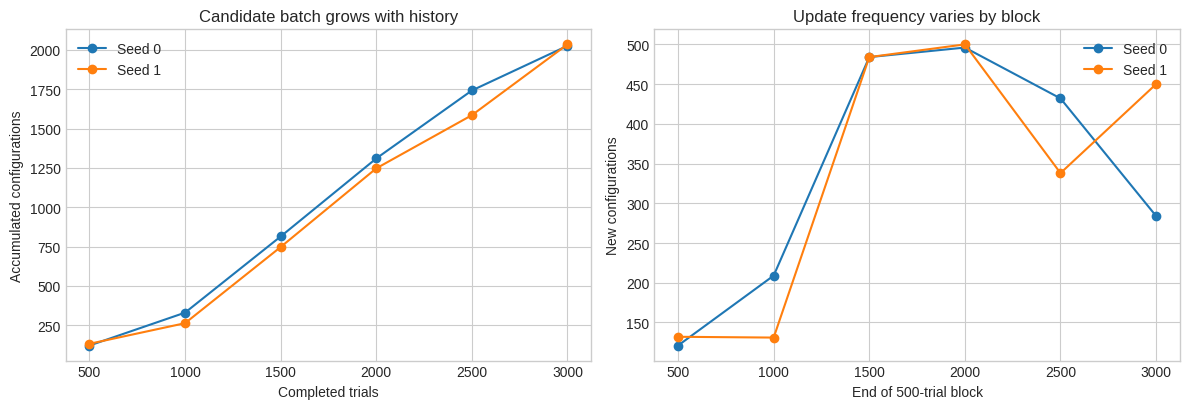

In [7]:
config_rows = []
for seed in SEEDS:
    fixed = runs[("fixed_batched", seed)]
    previous = 0
    for n in range(500, len(fixed["trials"]) + 1, 500):
        count = int(fixed["trials"].iloc[:n]["config_id"].nunique())
        config_rows.append({"seed": seed, "trials": n, "configurations": count, "new_configurations_in_block": count - previous})
        previous = count
config_df = pd.DataFrame(config_rows)
display(config_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for seed in SEEDS:
    part = config_df[config_df.seed == seed]
    axes[0].plot(part.trials, part.configurations, marker="o", label=f"Seed {seed}")
    axes[1].plot(part.trials, part.new_configurations_in_block, marker="o", label=f"Seed {seed}")
axes[0].set(xlabel="Completed trials", ylabel="Accumulated configurations", title="Candidate batch grows with history")
axes[1].set(xlabel="End of 500-trial block", ylabel="New configurations", title="Update frequency varies by block")
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

### Time gaps at model-update boundaries

With `retrain_after=8`, new configuration IDs `2, 10, 18, ...` mark the evaluations immediately following model/acquisition updates. The gap before each such evaluation includes training, `_get_x_best`, acquisition optimization, and related SMAC work, so it is **not** a pure `_get_x_best` timer. It is useful localization evidence: the old run's growing delay should appear specifically at these boundaries.

,seed,mode,boundaries,total_boundary_minutes,slope_ms_per_added_config,intercept_seconds,r_squared
0,0,Original singleton,254,373.774,72.874,14.399,0.871
1,0,Fixed batched,254,105.048,5.734,19.000,0.021
2,1,Original singleton,255,470.153,83.109,26.019,0.832
3,1,Fixed batched,255,75.569,6.009,11.664,0.045


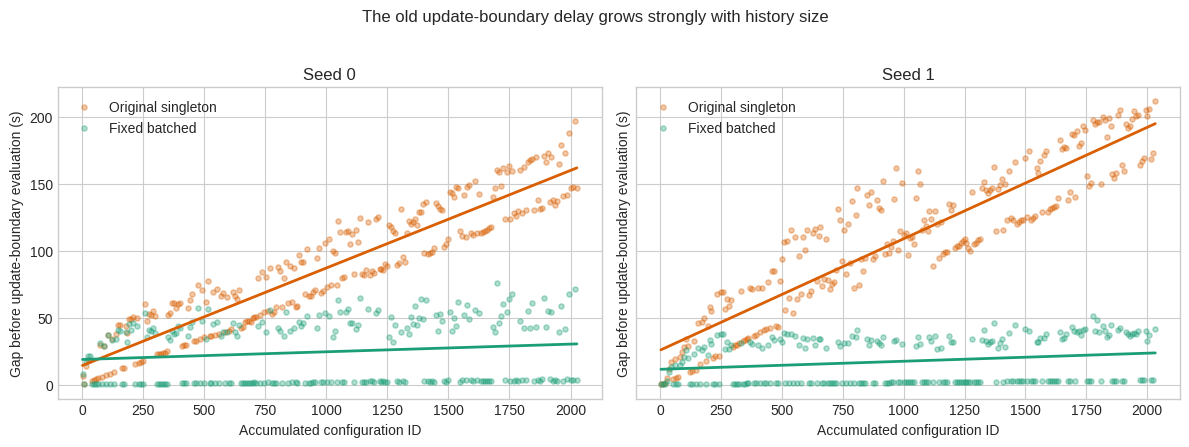

In [8]:
def update_boundary_gaps(run, max_config_id):
    trials = run["trials"].copy()
    trials["gap_before_seconds"] = trials["starttime"] - trials["endtime"].shift(1)
    first_for_config = ~trials["config_id"].duplicated()
    update_id = ((trials["config_id"].astype(int) - 2) % 8 == 0)
    result = trials[first_for_config & update_id & (trials["config_id"] <= max_config_id)].copy()
    return result[["config_id", "gap_before_seconds"]].dropna()

def linear_fit(frame):
    x = frame["config_id"].to_numpy(dtype=float)
    y = frame["gap_before_seconds"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    fitted = intercept + slope * x
    r2 = 1 - np.square(y - fitted).sum() / np.square(y - y.mean()).sum()
    return slope, intercept, r2

boundary_frames = {}
fit_rows = []
for seed in SEEDS:
    common_n = int(correctness_df.loc[correctness_df.seed == seed, "comparable_trials"].iloc[0])
    max_config_id = int(runs[("fixed_batched", seed)]["trials"].iloc[:common_n]["config_id"].max())
    for mode in MODES:
        frame = update_boundary_gaps(runs[(mode, seed)], max_config_id)
        boundary_frames[(mode, seed)] = frame
        slope, intercept, r2 = linear_fit(frame)
        fit_rows.append({
            "seed": seed,
            "mode": LABELS[mode],
            "boundaries": len(frame),
            "total_boundary_minutes": frame.gap_before_seconds.sum() / 60,
            "slope_ms_per_added_config": 1000 * slope,
            "intercept_seconds": intercept,
            "r_squared": r2,
        })

fit_df = pd.DataFrame(fit_rows)
display(fit_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for seed, ax in zip(SEEDS, axes):
    for mode in MODES:
        frame = boundary_frames[(mode, seed)]
        slope, intercept, _ = linear_fit(frame)
        ax.scatter(frame.config_id, frame.gap_before_seconds, s=14, alpha=0.35, color=COLORS[mode], label=LABELS[mode])
        xline = np.array([frame.config_id.min(), frame.config_id.max()])
        ax.plot(xline, intercept + slope * xline, color=COLORS[mode], linewidth=2)
    ax.set(title=f"Seed {seed}", xlabel="Accumulated configuration ID", ylabel="Gap before update-boundary evaluation (s)")
    ax.legend()
fig.suptitle("The old update-boundary delay grows strongly with history size", y=1.03)
fig.tight_layout()
plt.show()

## 5. Direct profiling of the fixed `_get_x_best`

The fixed runs are complete, so their event profiles are final. `candidate_inputs` counts configuration rows passed to the marginalized predictor. `expanded_config_instance_inputs` counts the corresponding rows after marginalization over 150 instances.

,seed,wall_hours,xbest_executions,xbest_prediction_calls,candidate_inputs,average_candidates_per_call,expanded_config_instance_inputs,invocation_reduction_vs_singleton,xbest_seconds,xbest_pct_wall,model_train_seconds,model_train_pct_wall,other_prediction_calls,other_prediction_seconds,other_prediction_pct_wall,target_seconds,target_pct_wall
0,0,3.702,254,254,257302,1013.0,38595300,1013.0,92.325,0.693,194.351,1.458,67010,10231.060,76.776,19.362,0.145
1,1,2.799,255,255,259335,1017.0,38900250,1017.0,82.853,0.822,201.409,1.999,66091,7379.077,73.230,15.209,0.151


,Marginalized prediction outside xbest,get_x_best,RF training,Target function,Other SMAC / uninstrumented
seed,,,,,
0,76.78,0.69,1.46,0.15,20.93
1,73.23,0.82,2.00,0.15,23.80


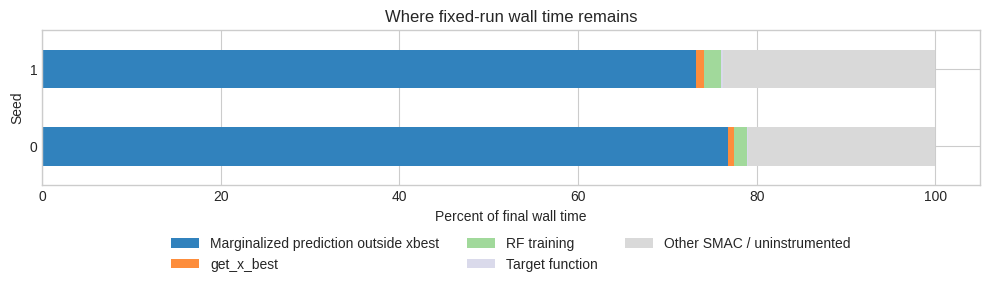

In [9]:
def phase(summary, name):
    return summary["phase_summary"][name]

profile_rows = []
for seed in SEEDS:
    summary = runs[("fixed_batched", seed)]["summary"]
    wall = summary["walltime_seconds"]
    xbest = phase(summary, "get_x_best")
    xbest_predict = phase(summary, "get_x_best_predict_marginalized")
    other_predict = phase(summary, "predict_marginalized")
    train = phase(summary, "model_train")
    profile_rows.append({
        "seed": seed,
        "wall_hours": wall / 3600,
        "xbest_executions": xbest["calls"],
        "xbest_prediction_calls": xbest_predict["calls"],
        "candidate_inputs": xbest_predict["total_inputs"],
        "average_candidates_per_call": xbest_predict["total_inputs"] / xbest_predict["calls"],
        "expanded_config_instance_inputs": xbest_predict["total_expanded_inputs"],
        "invocation_reduction_vs_singleton": xbest_predict["total_inputs"] / xbest_predict["calls"],
        "xbest_seconds": xbest["total_seconds_inclusive"],
        "xbest_pct_wall": 100 * xbest["total_seconds_inclusive"] / wall,
        "model_train_seconds": train["total_seconds_inclusive"],
        "model_train_pct_wall": 100 * train["total_seconds_inclusive"] / wall,
        "other_prediction_calls": other_predict["calls"],
        "other_prediction_seconds": other_predict["total_seconds_inclusive"],
        "other_prediction_pct_wall": 100 * other_predict["total_seconds_inclusive"] / wall,
        "target_seconds": summary["target_function_walltime_seconds"],
        "target_pct_wall": 100 * summary["target_function_walltime_seconds"] / wall,
    })

profile_df = pd.DataFrame(profile_rows)
display(profile_df.round(3))
assert (profile_df.xbest_executions == profile_df.xbest_prediction_calls).all()

# Do not add inclusive phases. This residual uses only non-overlapping top-level categories.
breakdown_rows = []
for row in profile_df.itertuples():
    used = row.other_prediction_pct_wall + row.xbest_pct_wall + row.model_train_pct_wall + row.target_pct_wall
    breakdown_rows.append({
        "seed": row.seed,
        "Marginalized prediction outside xbest": row.other_prediction_pct_wall,
        "get_x_best": row.xbest_pct_wall,
        "RF training": row.model_train_pct_wall,
        "Target function": row.target_pct_wall,
        "Other SMAC / uninstrumented": 100 - used,
    })
breakdown_df = pd.DataFrame(breakdown_rows).set_index("seed")
display(breakdown_df.round(2))

ax = breakdown_df.plot.barh(stacked=True, figsize=(10, 3.2), colormap="tab20c")
ax.set(xlabel="Percent of final wall time", ylabel="Seed", title="Where fixed-run wall time remains")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.tight_layout()
plt.show()

### Batched `_get_x_best` still scales linearly, but with a small constant

Each point below is one complete `_get_x_best` execution. There is exactly one high-level marginalized-prediction invocation for that execution; internally it evaluates the whole candidate batch over all 150 instances.

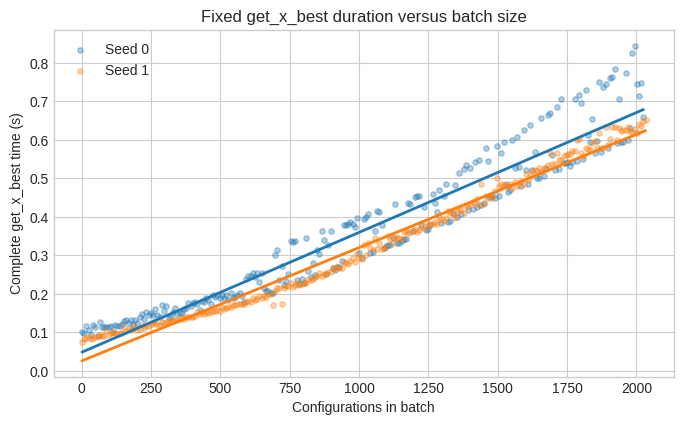

,seed,intercept_seconds,slope_ms_per_candidate,r_squared,largest_batch,predicted_seconds_at_largest_batch
0,0,0.0481,0.3113,0.9216,2025,0.6786
1,1,0.0256,0.2943,0.9811,2033,0.6239


In [10]:
xbest_fit_rows = []
fig, ax = plt.subplots(figsize=(8, 4.5))
for seed in SEEDS:
    events = pd.DataFrame(runs[("fixed_batched", seed)]["events"])
    points = events[events.phase == "get_x_best"].copy()
    x = points.n_inputs.to_numpy(dtype=float)
    y = points.seconds.to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    fitted = intercept + slope * x
    r2 = 1 - np.square(y - fitted).sum() / np.square(y - y.mean()).sum()
    xbest_fit_rows.append({"seed": seed, "intercept_seconds": intercept, "slope_ms_per_candidate": 1000 * slope, "r_squared": r2, "largest_batch": int(x.max()), "predicted_seconds_at_largest_batch": intercept + slope * x.max()})
    ax.scatter(x, y, s=15, alpha=0.35, label=f"Seed {seed}")
    line = np.array([x.min(), x.max()])
    ax.plot(line, intercept + slope * line, linewidth=2)
ax.set(xlabel="Configurations in batch", ylabel="Complete get_x_best time (s)", title="Fixed get_x_best duration versus batch size")
ax.legend()
plt.show()
xbest_fit_df = pd.DataFrame(xbest_fit_rows)
display(xbest_fit_df.round(4))

## 6. Controlled 1,000-trial function-level cross-check

The original `04_compare_fix` event buffers are written only when those jobs finish. Until then, the earlier `03_test_runtime/baseline` profiles provide a controlled cross-check at the same benchmark settings and the same first 1,000-trial trajectories. In the old profiler, the singleton calls immediately between `model_train` and `random_search` are the `_get_x_best` scan. The comparison below matches the same logical candidate rows and update count.

This is supporting evidence rather than the primary end-to-end result because the jobs ran on different Slurm nodes.

In [11]:
BASELINE_03 = HERE.parent / "03_test_runtime" / "results" / "baseline"

def old_xbest_events(seed):
    events = read_json(BASELINE_03 / str(seed) / "runtime_events.json")
    selected = []
    for index, event in enumerate(events):
        if event["phase"] != "model_train":
            continue
        group = []
        for following in events[index + 1:]:
            if following["phase"] == "random_search":
                break
            if following["phase"] == "predict_marginalized" and following.get("n_inputs") == 1:
                group.append(following)
        assert len(group) == event["configurations"]
        selected.extend(group)
    return selected

crosscheck_rows = []
for seed in SEEDS:
    old = old_xbest_events(seed)
    fixed = [event for event in runs[("fixed_batched", seed)]["events"] if event["phase"] == "get_x_best_predict_marginalized" and event["finished_trials"] < 1000]
    old_seconds = sum(event["seconds"] for event in old)
    fixed_seconds = sum(event["seconds"] for event in fixed)
    old_inputs = sum(event["n_inputs"] for event in old)
    fixed_inputs = sum(event["n_inputs"] for event in fixed)
    assert old_inputs == fixed_inputs
    crosscheck_rows.append({
        "seed": seed,
        "model_updates": len(fixed),
        "logical_candidate_inputs": fixed_inputs,
        "old_high_level_calls": len(old),
        "fixed_high_level_calls": len(fixed),
        "call_reduction": len(old) / len(fixed),
        "old_seconds": old_seconds,
        "fixed_seconds": fixed_seconds,
        "measured_prediction_speedup": old_seconds / fixed_seconds,
    })
crosscheck_df = pd.DataFrame(crosscheck_rows)
display(crosscheck_df.round(3))

,seed,model_updates,logical_candidate_inputs,old_high_level_calls,fixed_high_level_calls,call_reduction,old_seconds,fixed_seconds,measured_prediction_speedup
0,0,42,6930,6930,42,165.0,480.324,5.378,89.321
1,1,33,4257,4257,33,129.0,279.867,3.319,84.319


## 7. Conclusions and limitations

In [12]:
latest_checkpoint = int(pooled_checkpoint_df.trials.max())
pooled_latest = pooled_checkpoint_df[pooled_checkpoint_df.trials == latest_checkpoint].iloc[0]
pooled_latest_interval = pooled_interval_df[pooled_interval_df.interval_end == latest_checkpoint].iloc[0]
fixed0 = profile_df[profile_df.seed == 0].iloc[0]
fixed1 = profile_df[profile_df.seed == 1].iloc[0]
all_complete = all(runs[("original_singleton", seed)]["summary"] is not None for seed in SEEDS)
completion_text = "Both original runs are complete." if all_complete else "The original 3,000-trial runs are not complete, so no final paired 3,000-trial speedup is reported."

display(Markdown(f"""
### What the current data supports

1. **The fix preserves behavior in the observed data.** Both seeds have an exact match in configuration values and every non-timing trial field through {int(correctness_df.comparable_trials.min()):,} or more common trials. There is no observed trajectory divergence.

2. **The end-to-end gain grows as the history grows.** Pooled cumulative runtime through {latest_checkpoint:,} trials is **{pooled_latest.speedup:.2f}× faster** ({pooled_latest.time_reduction_pct:.1f}% less time). In the latest 500-trial block alone, the pooled speedup is **{pooled_latest_interval.speedup:.2f}×**.

3. **The change removes the specific singleton-dispatch pathology.** Across the complete fixed runs, `_get_x_best` made one high-level batched marginalized-prediction invocation per execution: {int(fixed0.xbest_prediction_calls)} calls for seed 0 and {int(fixed1.xbest_prediction_calls)} for seed 1. Those calls processed {int(fixed0.candidate_inputs):,} and {int(fixed1.candidate_inputs):,} configuration rows. The equivalent row-at-a-time implementation would therefore make roughly **{fixed0.invocation_reduction_vs_singleton:.0f}×** and **{fixed1.invocation_reduction_vs_singleton:.0f}×** as many high-level invocations while doing the same logical prediction work.

4. **`_get_x_best` is no longer the bottleneck.** It occupies only {fixed0.xbest_pct_wall:.2f}% and {fixed1.xbest_pct_wall:.2f}% of fixed-run wall time. Marginalized predictions outside `_get_x_best`—predominantly acquisition/local-search work—still occupy {fixed0.other_prediction_pct_wall:.1f}% and {fixed1.other_prediction_pct_wall:.1f}%. RF training is {fixed0.model_train_pct_wall:.1f}%/{fixed1.model_train_pct_wall:.1f}%, and the surrogate target function is only {fixed0.target_pct_wall:.2f}%/{fixed1.target_pct_wall:.2f}%.

5. **The slowness is SMAC overhead, not target evaluation.** More than 99.8% of fixed-run wall time lies outside the surrogate target function. Batching `_get_x_best` solves one major scaling problem; acquisition-search prediction is now the largest remaining optimization target.

### Limitations

- {completion_text}
- There are only two seeds, and paired jobs ran on different compute nodes. The growing within-run trend and exact paired trajectories are stronger evidence than either seed's standalone headline ratio.
- Profiler phase timings are inclusive and must not be added blindly. In particular, `get_x_best_predict_marginalized` is contained inside `get_x_best`.
- Equal-trial checkpoint timing begins at the first target evaluation and omits startup/cleanup; final `walltime_seconds` is used for completed-run totals.
- The fix reduces call overhead, not asymptotic prediction work: a batched update still evaluates all accumulated configurations over all 150 instances.
- The benefit is specific to this history-heavy, feature-marginalized benchmark setup. It will be smaller when histories are short, retraining is rare, or real target evaluations dominate wall time.
"""))


### What the current data supports

1. **The fix preserves behavior in the observed data.** Both seeds have an exact match in configuration values and every non-timing trial field through 3,000 or more common trials. There is no observed trajectory divergence.

2. **The end-to-end gain grows as the history grows.** Pooled cumulative runtime through 3,000 trials is **2.66× faster** (62.4% less time). In the latest 500-trial block alone, the pooled speedup is **3.48×**.

3. **The change removes the specific singleton-dispatch pathology.** Across the complete fixed runs, `_get_x_best` made one high-level batched marginalized-prediction invocation per execution: 254 calls for seed 0 and 255 for seed 1. Those calls processed 257,302 and 259,335 configuration rows. The equivalent row-at-a-time implementation would therefore make roughly **1013×** and **1017×** as many high-level invocations while doing the same logical prediction work.

4. **`_get_x_best` is no longer the bottleneck.** It occupies only 0.69% and 0.82% of fixed-run wall time. Marginalized predictions outside `_get_x_best`—predominantly acquisition/local-search work—still occupy 76.8% and 73.2%. RF training is 1.5%/2.0%, and the surrogate target function is only 0.15%/0.15%.

5. **The slowness is SMAC overhead, not target evaluation.** More than 99.8% of fixed-run wall time lies outside the surrogate target function. Batching `_get_x_best` solves one major scaling problem; acquisition-search prediction is now the largest remaining optimization target.

### Limitations

- Both original runs are complete.
- There are only two seeds, and paired jobs ran on different compute nodes. The growing within-run trend and exact paired trajectories are stronger evidence than either seed's standalone headline ratio.
- Profiler phase timings are inclusive and must not be added blindly. In particular, `get_x_best_predict_marginalized` is contained inside `get_x_best`.
- Equal-trial checkpoint timing begins at the first target evaluation and omits startup/cleanup; final `walltime_seconds` is used for completed-run totals.
- The fix reduces call overhead, not asymptotic prediction work: a batched update still evaluates all accumulated configurations over all 150 instances.
- The benefit is specific to this history-heavy, feature-marginalized benchmark setup. It will be smaller when histories are short, retraining is rare, or real target evaluations dominate wall time.
